In [1]:
import pandas as pd
from itertools import combinations
from collections import Counter

df = pd.read_csv("/content/Task29_Dataset_online_retail.csv")

In [2]:
print(df.shape)
print(df.columns.tolist())
df.head()

(5482, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536366,22961,JAM MAKING SET PRINTED,2,2011-01-27 09:17:00,1.45,12673,United Kingdom
1,536366,22960,JAM MAKING SET WITH JARS,8,2011-01-27 09:17:00,4.25,12673,United Kingdom
2,536367,85123A,WHITE HANGING HEART T-LIGHT HOLDER,8,2010-12-16 09:43:00,2.95,12362,United Kingdom
3,536367,71053,WHITE METAL LANTERN,4,2010-12-16 09:43:00,3.75,12362,United Kingdom
4,536367,21730,GLASS STAR FROSTED T-LIGHT HOLDER,12,2010-12-16 09:43:00,4.25,12362,United Kingdom


In [3]:
df = df.dropna(subset=["Description"])
df["Invoice"] = df["Invoice"].astype(str)

df = df[~df["Invoice"].str.startswith("C")]

df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

non_products = ["POST", "DOT", "M", "D", "C2", "BANK CHARGES", "AMAZONFEE", "S", "B", "CRUK"]
df = df[~df["StockCode"].astype(str).isin(non_products)]

df["Description"] = df["Description"].str.strip()
print(df.shape)

(5482, 8)


In [4]:
top_items = df["Description"].value_counts().head(200).index
df_small = df[df["Description"].isin(top_items)]

baskets = df_small.groupby("Invoice")["Description"].apply(lambda x: sorted(set(x)))
baskets = baskets[baskets.apply(len) >= 2]
print(len(baskets))

1327


In [5]:
pair_counts = Counter()
for items in baskets:
    for pair in combinations(items, 2):
        pair_counts[pair] += 1

top_pairs = pd.DataFrame(pair_counts.most_common(15),
                         columns=["Product Pair", "Times Bought Together"])
top_pairs

,Product Pair,Times Bought Together
0,"(PAPER CHAIN KIT 50'S CHRISTMAS, PARTY BUNTING)",137
1,"(JUMBO BAG BAROQUE BLACK WHITE, JUMBO BAG PINK...",122
2,"(JUMBO BAG BAROQUE BLACK WHITE, JUMBO BAG RED ...",122
3,"(REGENCY CAKESTAND 3 TIER, SET OF 3 CAKE TINS ...",119
4,"(JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROS...",118
5,"(PACK OF 72 RETROSPOT CAKE CASES, REGENCY CAKE...",118
6,"(PACK OF 60 PINK PAISLEY CAKE CASES, REGENCY C...",117
7,"(JAM MAKING SET PRINTED, JAM MAKING SET WITH J...",114
8,"(LUNCH BAG BLACK SKULL, LUNCH BAG RED RETROSPOT)",112
9,"(WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...",111


In [6]:
n_orders = len(baskets)
item_counts = Counter(i for items in baskets for i in items)

rows = []
for (a, b), c in pair_counts.items():
    if c < 50:
        continue
    support = c / n_orders
    conf_ab = c / item_counts[a]
    conf_ba = c / item_counts[b]
    lift = conf_ab / (item_counts[b] / n_orders)
    rows.append([a, b, c, round(support, 4), round(conf_ab, 3), round(lift, 2)])
    rows.append([b, a, c, round(support, 4), round(conf_ba, 3), round(lift, 2)])

rules = pd.DataFrame(rows, columns=["Product A", "Product B", "Count", "Support", "Confidence", "Lift"])
rules = rules.sort_values("Lift", ascending=False)
rules.head(10)

,Product A,Product B,Count,Support,Confidence,Lift
33,LUNCH BAG RED RETROSPOT,LUNCH BAG BLACK SKULL,112,0.0844,0.640,4.67
32,LUNCH BAG BLACK SKULL,LUNCH BAG RED RETROSPOT,112,0.0844,0.615,4.67
30,BAKING SET 9 PIECE RETROSPOT,RETROSPOT TEA SET CERAMIC 11 PC,98,0.0739,0.563,4.59
31,RETROSPOT TEA SET CERAMIC 11 PC,BAKING SET 9 PIECE RETROSPOT,98,0.0739,0.601,4.59
5,WHITE METAL LANTERN,GLASS STAR FROSTED T-LIGHT HOLDER,101,0.0761,0.577,4.14
4,GLASS STAR FROSTED T-LIGHT HOLDER,WHITE METAL LANTERN,101,0.0761,0.546,4.14
36,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,109,0.0821,0.623,4.11
37,LUNCH BAG SPACEBOY DESIGN,LUNCH BAG RED RETROSPOT,109,0.0821,0.542,4.11
20,HAND WARMER RED POLKA DOT,KNITTED UNION FLAG HOT WATER BOTTLE,95,0.0716,0.537,4.05
21,KNITTED UNION FLAG HOT WATER BOTTLE,HAND WARMER RED POLKA DOT,95,0.0716,0.540,4.05


In [7]:
def recommend(product, n=3):
    r = rules[rules["Product A"] == product].sort_values("Confidence", ascending=False)
    return r[["Product B", "Confidence", "Lift"]].head(n)

sample_product = top_pairs.iloc[0]["Product Pair"][0]
print("Customers who bought:", sample_product)
recommend(sample_product)

Customers who bought: PAPER CHAIN KIT 50'S CHRISTMAS


,Product B,Confidence,Lift
16,PARTY BUNTING,0.626,3.69


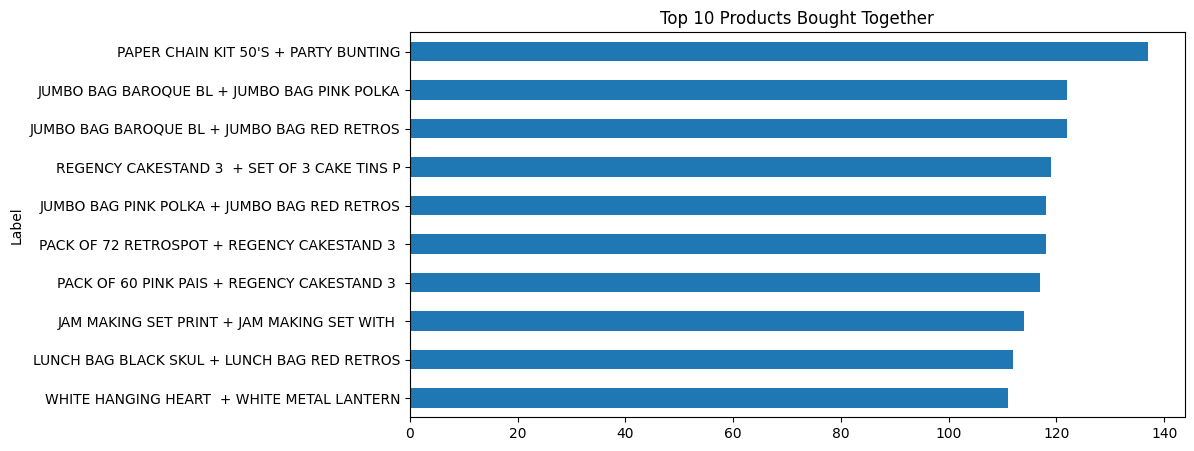

In [8]:
import matplotlib.pyplot as plt
top_pairs["Label"] = top_pairs["Product Pair"].apply(lambda p: f"{p[0][:20]} + {p[1][:20]}")
top_pairs.head(10).plot.barh(x="Label", y="Times Bought Together", figsize=(10, 5), legend=False)
plt.gca().invert_yaxis()
plt.title("Top 10 Products Bought Together")
plt.show()

**Conclusion**

In this task, I performed a Product Basket Analysis using Python and Pandas to identify products that are frequently purchased together. The data was first cleaned by removing missing descriptions, cancelled orders, zero or negative quantities and non-product entries. I then kept the 200 most popular products and grouped the transactions by invoice number, which gave 1,327 orders containing at least two products. All unique product pairs were generated for each order, excluding self-pairs.

The most frequently purchased pair was Paper Chain Kit 50's Christmas and Party Bunting, bought together in 137 orders. This was followed by Jumbo Bag Baroque Black White with Jumbo Bag Pink Polkadot and Jumbo Bag Baroque Black White with Jumbo Bag Red Retrospot (122 orders each), and Regency Cakestand 3 Tier with Set of 3 Cake Tins (119 orders).

To measure the strength of these associations, I calculated Support, Confidence and Lift. The strongest association was between Lunch Bag Red Retrospot and Lunch Bag Black Skull, with a Lift of 4.67, a Support of 0.0844 and a Confidence of 0.64. This means customers who buy one of these bags are about 4.7 times more likely to buy the other than would be expected by chance. Other strong associations were Baking Set 9 Piece Retrospot with Retrospot Tea Set Ceramic 11 PC (Lift 4.59) and White Metal Lantern with Glass Star Frosted T-Light Holder (Lift 4.14). All of the top pairs had Lift values well above 1, confirming genuine relationships between these products.

The analysis also showed that most of the top pairs belong to the same product family or design theme, such as matching lunch bags, jumbo bags, kitchen sets and decorative items. Customers clearly tend to buy complementary or matching products together.

Using these results, I built a simple recommendation function. For example, customers who buy Paper Chain Kit 50's Christmas are recommended Party Bunting, with a Confidence of 0.626 and a Lift of 3.69.